In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np

print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")
print(torch.cuda.get_device_capability())

PyTorch: 2.9.1+cu128
CUDA: True
(12, 0)


In [3]:
CONFIG = {
    "batch_size": 32,
    "epochs": 10,
    "learning_rate": 0.001,
    "num_classes": 38,
    "image_size": 224,
    "data_dir": "../data/raw/plantvillage",
    "train_dir": "../data/raw/plantvillage/train",
    "val_dir": "../data/raw/plantvillage/val",
    "model_path": "../models/mobilenetv2_agrivision.pt",
}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {DEVICE}")

Using: cuda


In [7]:
train_transform = transforms.Compose([
    transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [8]:
train_dataset = datasets.ImageFolder(CONFIG["train_dir"], transform=train_transform)
val_dataset = datasets.ImageFolder(CONFIG["val_dir"], transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=0)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Number of classes: {len(train_dataset.classes)}")
print(f"Classes: {train_dataset.classes}")

Training samples: 43444
Validation samples: 10861
Number of classes: 38
Classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria

In [ ]:
model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)

for param in model.features.parameters():
    param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Dropout(p=0.2),
    nn.Linear(1280, 128),
    nn.ReLU(),
    nn.Linear(128, CONFIG["num_classes"]),
)

model = model.to(DEVICE)
print(f"Model created with custom top layers:")
print(f"  - Global Average Pooling (1280 features)")
print(f"  - Dense: 128 neurons, ReLU activation")
print(f"  - Output: {CONFIG['num_classes']} neurons (Softmax)")
print(model.classifier)

Model created with custom top layers:
  - Global Average Pooling (1280 features)
  - Dense: 128 neurons, ReLU activation
  - Output: 38 neurons (Softmax)
Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=128, bias=True)
  (2): ReLU()
  (3): Linear(in_features=128, out_features=38, bias=True)
)


In [6]:
# Training Functions
# Loss: CrossEntropyLoss (combines LogSoftmax + NLLLoss, equivalent to categorical cross-entropy)
# Optimizer: Adam - adaptive learning rate optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=CONFIG["learning_rate"])

print(f"Loss Function: CrossEntropyLoss (Categorical Cross-Entropy)")
print(f"Optimizer: Adam (lr={CONFIG['learning_rate']})")

def train_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in tqdm(loader, desc="Training"):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    return running_loss / len(loader), correct / total

def validate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validating"):
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    return running_loss / len(loader), correct / total

Loss Function: CrossEntropyLoss (Categorical Cross-Entropy)
Optimizer: Adam (lr=0.001)


In [7]:
# Training Loop
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(CONFIG["epochs"]):
    print(f"\nEpoch {epoch+1}/{CONFIG['epochs']}")
    
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = validate(model, val_loader, criterion)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")


Epoch 1/10


Validating: 100%|██████████| 340/340 [00:22<00:00, 15.31it/s]


Train Loss: 0.4145, Train Acc: 0.8713
Val Loss: 0.1369, Val Acc: 0.9526

Epoch 2/10


Validating: 100%|██████████| 340/340 [00:18<00:00, 18.01it/s]


Train Loss: 0.1750, Train Acc: 0.9437
Val Loss: 0.1605, Val Acc: 0.9535

Epoch 3/10


...

Train Loss: 0.0846, Train Acc: 0.9726
Val Loss: 0.0628, Val Acc: 0.9796

Epoch 9/10


Validating: 100%|██████████| 340/340 [00:19<00:00, 17.79it/s]


Train Loss: 0.0792, Train Acc: 0.9739
Val Loss: 0.0510, Val Acc: 0.9847

Epoch 10/10


Validating: 100%|██████████| 340/340 [00:16<00:00, 20.72it/s]

Train Loss: 0.0760, Train Acc: 0.9761
Val Loss: 0.0513, Val Acc: 0.9842


In [8]:
# Save Model
os.makedirs(os.path.dirname(CONFIG["model_path"]), exist_ok=True)

torch.save({
    "model_state_dict": model.state_dict(),
    "class_names": train_dataset.classes,
    "config": CONFIG
}, CONFIG["model_path"])

print(f"Model saved to {CONFIG['model_path']}")

Model saved to ../models/mobilenetv2_agrivision.pt


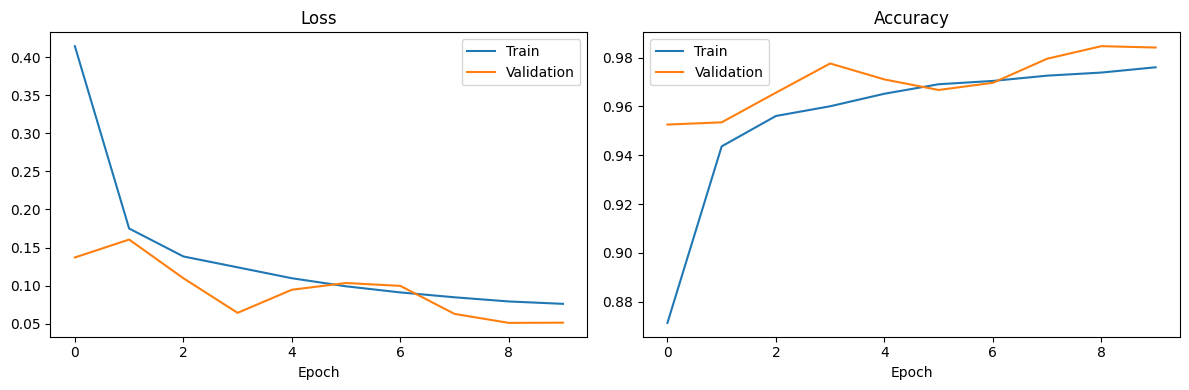

In [9]:
# Visualize Results
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses, label='Train')
axes[0].plot(val_losses, label='Validation')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(train_accs, label='Train')
axes[1].plot(val_accs, label='Validation')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig('../models/training_history.png')
plt.show()

Mean accuracy of last 3 epoch: 98.28%
Best single epoch accuracy: 98.47%

In [4]:
from torchvision import models
import torch.nn as nn

def load_trained_model(model_path, num_classes=38, device='cpu'):
    model = models.mobilenet_v2(weights=None)
    
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.2),
        nn.Linear(1280, 128),
        nn.ReLU(),
        nn.Linear(128, num_classes),
    )
    
    checkpoint = torch.load(model_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    
    return model, checkpoint.get("class_names", None)

loaded_model, class_names = load_trained_model(CONFIG["model_path"], device=DEVICE)
loaded_model = loaded_model.to(DEVICE)
print(f"Model loaded from {CONFIG['model_path']}")
print(f"Number of classes: {len(class_names)}")

Model loaded from ../models/mobilenetv2_agrivision.pt
Number of classes: 38


In [9]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

all_preds = []
all_labels = []

loaded_model.eval()
with torch.no_grad():
    for images, labels in tqdm(val_loader, desc="Generating predictions"):
        images = images.to(DEVICE)
        outputs = loaded_model(images)
        _, predicted = torch.max(outputs, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

print(f"Total predictions: {len(all_preds)}")

Generating predictions: 100%|██████████| 340/340 [00:22<00:00, 15.19it/s]

Total predictions: 10861


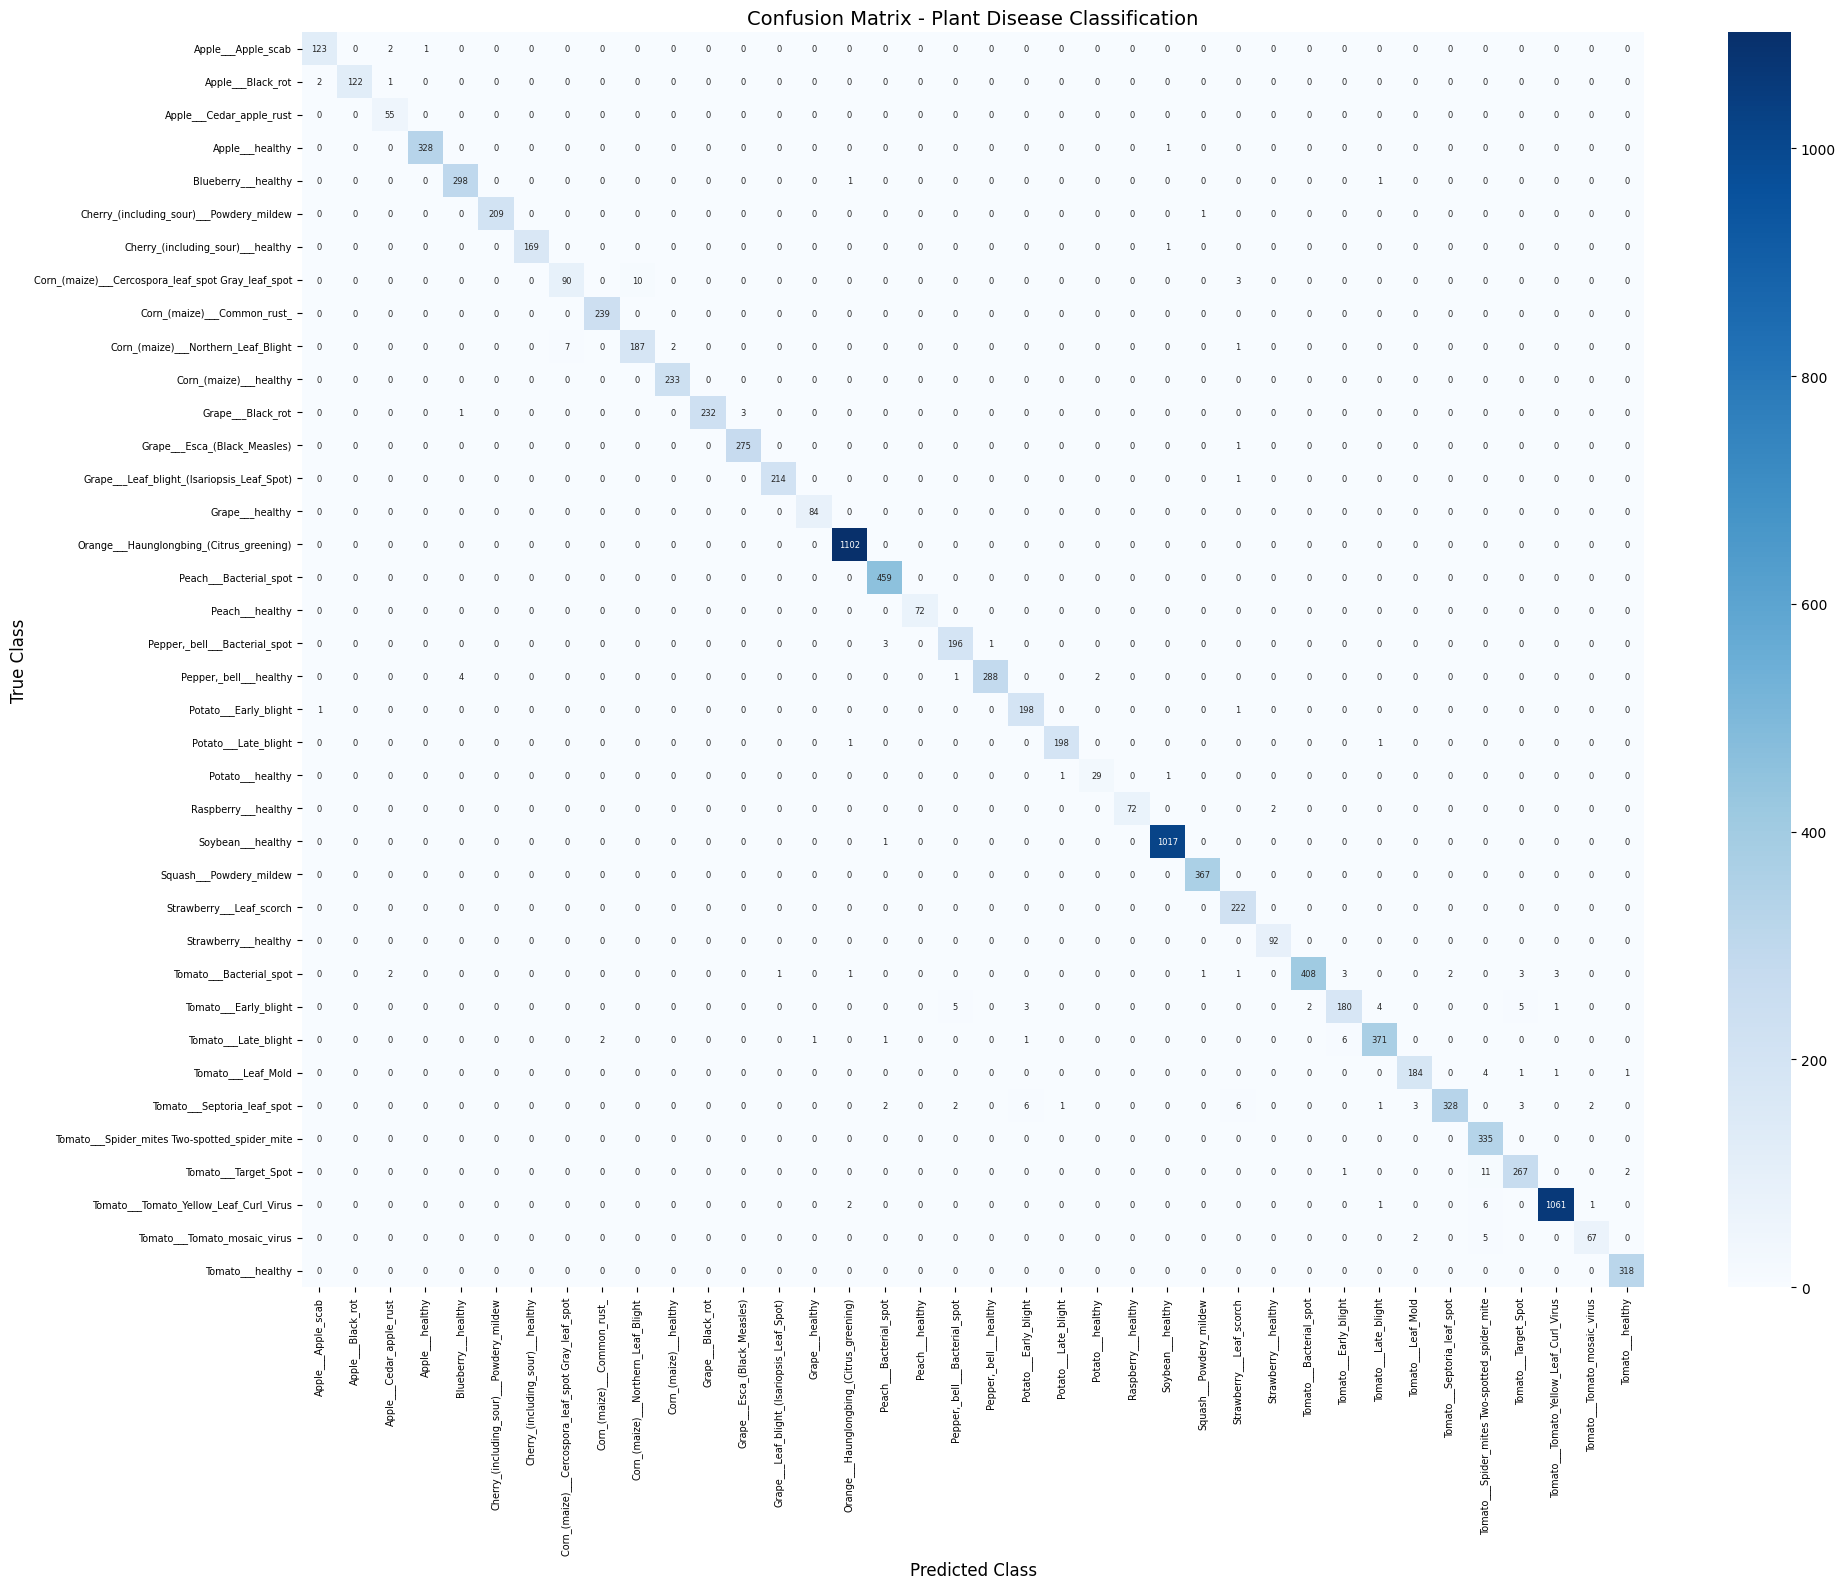


Per-class accuracy:
  Apple___Apple_scab: 0.9762
  Apple___Black_rot: 0.9760
  Apple___Cedar_apple_rust: 1.0000
  Apple___healthy: 0.9970
  Blueberry___healthy: 0.9933
  Cherry_(including_sour)___Powdery_mildew: 0.9952
  Cherry_(including_sour)___healthy: 0.9941
  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 0.8738
  Corn_(maize)___Common_rust_: 1.0000
  Corn_(maize)___Northern_Leaf_Blight: 0.9492
  Corn_(maize)___healthy: 1.0000
  Grape___Black_rot: 0.9831
  Grape___Esca_(Black_Measles): 0.9964
  Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 0.9953
  Grape___healthy: 1.0000
  Orange___Haunglongbing_(Citrus_greening): 1.0000
  Peach___Bacterial_spot: 1.0000
  Peach___healthy: 1.0000
  Pepper,_bell___Bacterial_spot: 0.9800
  Pepper,_bell___healthy: 0.9763
  Potato___Early_blight: 0.9900
  Potato___Late_blight: 0.9900
  Potato___healthy: 0.9355
  Raspberry___healthy: 0.9730
  Soybean___healthy: 0.9990
  Squash___Powdery_mildew: 1.0000
  Strawberry___Leaf_scorch: 1.0000
  Strawberry

In [10]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(20, 16))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names,
            annot_kws={"size": 6})
plt.title('Confusion Matrix - Plant Disease Classification', fontsize=14)
plt.xlabel('Predicted Class', fontsize=12)
plt.ylabel('True Class', fontsize=12)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.savefig('../models/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

class_accuracy = cm.diagonal() / cm.sum(axis=1)
print("\nPer-class accuracy:")
for i, (name, acc) in enumerate(zip(class_names, class_accuracy)):
    print(f"  {name}: {acc:.4f}")

In [ ]:
# Compute overall metrics: accuracy, precision, recall, F1
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report

# Fallback to dataset class names if checkpoint did not contain them
if class_names is None:
    class_names = val_dataset.classes

accuracy = accuracy_score(all_labels, all_preds)
precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
    all_labels, all_preds, average="weighted", zero_division=0
)
precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    all_labels, all_preds, average="macro", zero_division=0
)

print("Overall metrics (validation set):")
print(f"  Accuracy: {accuracy:.4f}")
print(f"  Precision (weighted): {precision_weighted:.4f}")
print(f"  Recall (weighted): {recall_weighted:.4f}")
print(f"  F1-score (weighted): {f1_weighted:.4f}")
print(f"  Precision (macro): {precision_macro:.4f}")
print(f"  Recall (macro): {recall_macro:.4f}")
print(f"  F1-score (macro): {f1_macro:.4f}")

print("\nDetailed classification report:")
print(classification_report(all_labels, all_preds, target_names=class_names, digits=4, zero_division=0))